# Additional Materials - SciPy, Pandas & Some Mini‑Projects

These notes extend the live session. The tone is practical: we focus on the tools you will actually use.
If you are comfortable with the basics of Python/NumPy/Matplotlib, this is the natural next step.

**What we will do**
- A short tour of **SciPy** (integration, ODE solvers, optimisation)
- A quick start with **Pandas** (tabular data, summaries, simple plots)
- Two short **mini‑projects** you can run and adapt

For that, you'll need to install `scipy` and `pandas`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, solve_ivp
from scipy.optimize import minimize
import pandas as pd

## 1. SciPy essentials

**SciPy** builds on NumPy and provides a broad set of numerical algorithms we use across several subjects in applied maths.
Here we keep it simple and relevant: **integration**, **ODEs**, and **optimisation**.

### 1.1 Numerical integration — `quad`

`quad` computes one‑dimensional definite integrals. It adapts the step size internally, so it is both convenient and robust for a wide range of smooth functions.

In [5]:
# ∫_0^π sin(x) dx = 2
f = lambda x: np.sin(x)
res, err = quad(func=f, a=0, b=np.pi)
print("Integral ≈", res, "  (error estimate:", err, ")")

Integral ≈ 2.0   (error estimate: 2.220446049250313e-14 )


#### 📝 Practice

Look at the function `scipy.integrate.dblquad` to compute
$$
I := \iint_{D} e^{-(x^2+y^2)}dxdy,\qquad D = \{(x,y) \in \mathbb{R}^2: x^2+y^2 \le 1\}.
$$
To do that, you can use
$$
I=\int_{-1}^{1}\int_{-\sqrt{1-x^2}}^{\sqrt{1-x^2}} e^{-(x^2+y^2)} dy dx.
$$

### 1.2 Differential equations — `solve_ivp`

We solve the scalar ODE $y'(t) = -y(t)$, with initial condition $y(0)=1$. 

The analytical solution is $y(t)=e^{-t}$.

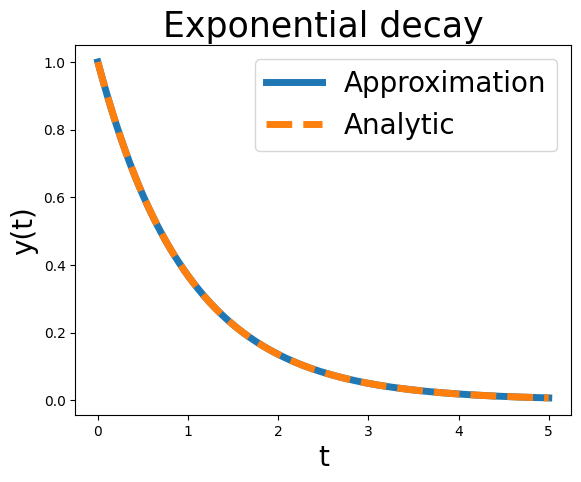

In [11]:
def dydt(t, y):
    return -y

sol = solve_ivp(dydt, t_span=(0, 5), y0=[1.0], dense_output=True)
t = np.linspace(0, 5, 200)
y = sol.sol(t)[0]

plt.plot(t, y, linewidth=5, label="Approximation")
plt.plot(t, np.exp(-t), linestyle="--", linewidth=5, label="Analytic")
plt.xlabel("t", fontsize=20)
plt.ylabel("y(t)", fontsize=20)
plt.title("Exponential decay", fontsize=25)
plt.legend(loc='upper right', fontsize=20)
plt.show()

#### 📝 Practice

Create a 1 by 2 plot using `plt.subplots` depicting the following two errors: $|y(t) - \tilde{y}(t)|$ and $|y(t) - \tilde{y}(t)|/|y(t)|$, where $\tilde{y}$ approximates the true solution $y(t)$.

In [20]:
#fig, ax = plt.subplots(....

### 1.3 Optimisation — `minimize`

We can use SciPy to minimise functions. There are a couple of methods that should be understood before applying them, but they can be used to address your problems.

We use the classic **Rosenbrock** function as a benchmark.

In [15]:
rosen = lambda x: (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2
res = minimize(rosen, x0=[0.0, 0.0], method="BFGS") #x0 is your initial guess

In [18]:
print("Converged:", res.success, "| f(x*) =", res.fun)
print("x* =", res.x)

Converged: True | f(x*) = 2.8440052847381483e-11
x* = [0.99999467 0.99998932]


#### 📝 Exercise A (quick checks)

1) Approximate $\int_{-\infty}^{\infty} e^{-x^2}\,dx$ by integrating on a large finite interval. Think of a way to define how large this interval should be (there is no unique correct answer). Then, compare the answer with the true value $\sqrt{\pi}$.

2) Solve the **logistic growth** ODE $y' = r y (1 - y/K)$ for a few parameter pairs $(r,K)$. Plot some of the results.

3) Minimize $g(x)=x^2 + \cos(3x)$ in 1D from different starting points. Make a scatter plot where $x$ is the initial guess and $y$ is the final value found by the algorithm. 

In [35]:
# 1) Gaussian integral (truncated)
from math import sqrt, pi
f = lambda x: np.exp(-x**2)
res_old = 0.0
for interval_size in range(1, 30):
    res, err = quad(f, -interval_size, interval_size)
    if np.abs(res - res_old)/np.abs(res) < 0.01:
        print(f'It is enough to have interval size of {interval_size}')
        break
    res_old = res
print("Truncated Gaussian ≈", res, "   sqrt(pi) =", sqrt(pi))

It is enough to have interval size of 3
Truncated Gaussian ≈ 1.7724146965190428    sqrt(pi) = 1.7724538509055159


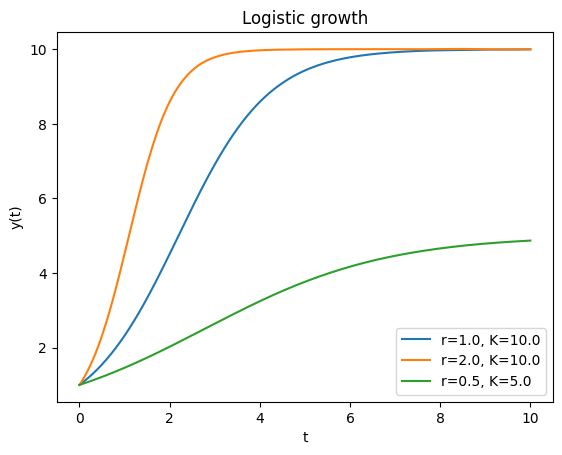

In [36]:
# 2) Logistic ODE
def logistic_rhs(t, y, r=1.0, K=10.0):
    return r * y * (1 - y / K)

plt.figure()
for (r, K) in [(1.0, 10.0), (2.0, 10.0), (0.5, 5.0)]:
    sol = solve_ivp(lambda t, y: logistic_rhs(t, y, r, K), (0, 10), [1.0], dense_output=True)
    T = np.linspace(0, 10, 200)
    plt.plot(T, sol.sol(T)[0], label=f"r={r}, K={K}")

plt.xlabel("t") 
plt.ylabel("y(t)")
plt.title("Logistic growth")
plt.legend()
plt.show()

In [37]:
# 3) 1D optimisation with multiple starts
g = lambda x: x[0]**2 + np.cos(3*x[0])
for x0 in [[-2.0], [0.2], [2.0]]:
    res = minimize(g, x0=x0, method="BFGS")
    print(f"start {x0[0]:>4.1f} -> x* ≈ {res.x[0]: .4f}, f(x*) = {res.fun: .6f}, success={res.success}")

start -2.0 -> x* ≈ -0.8471, f(x*) = -0.107592, success=True
start  0.2 -> x* ≈  0.8471, f(x*) = -0.107592, success=True
start  2.0 -> x* ≈  0.8471, f(x*) = -0.107592, success=True


## 2. Pandas essentials

**Pandas** provides the `DataFrame`, a table‑like structure with labelled columns and rich I/O. Think of it as a programmable spreadsheet that integrates nicely with NumPy and Matplotlib. This library has many tools, and using them is the best way to learn.

In [3]:
rng = np.random.default_rng(0) # for reproducibility 
df = pd.DataFrame({
    "time": np.arange(0, 50),
    "signal": np.cumsum(rng.normal(0.0, 1.0, 50)),
    "group": ["A"]*25 + ["B"]*25,
})
df.head() # take the first five items in the dataframe

,time,signal,group
0,0,0.125730,A
1,1,-0.006375,A
2,2,0.634048,A
3,3,0.738948,A
4,4,0.203279,A


### 2.1 Descriptives and simple plotting

,time,signal
count,50.00000,50.000000
mean,24.50000,-1.641874
std,14.57738,2.806123
min,0.00000,-5.117710
25%,12.25000,-3.899600
50%,24.50000,-2.348372
75%,36.75000,0.227427
max,49.00000,6.449824


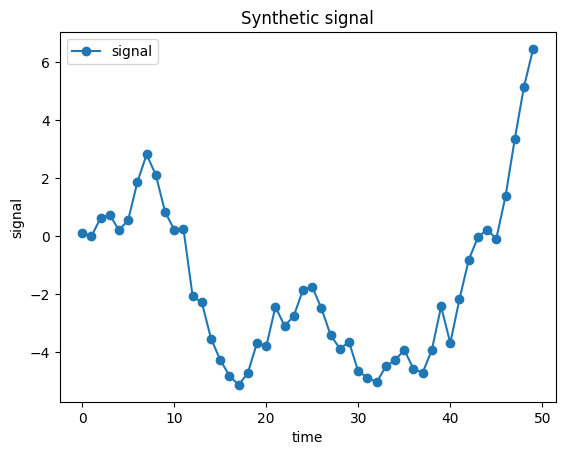

In [4]:
display(df.describe()) #some statistics from the dataframe

ax = df.plot(x="time", y="signal", marker="o", linestyle="-", title="Synthetic signal")
ax.set_xlabel("time")
ax.set_ylabel("signal")
plt.show()

### 2.2 Slicing

Here we have `loc`, which localise a specific **index** and `iloc`, which select a row.

In [10]:
df.loc[3]

time             3
signal    0.738948
group            A
Name: 3, dtype: object

In [8]:
df.iloc[0:5]

,time,signal,group
0,0,0.125730,A
1,1,-0.006375,A
2,2,0.634048,A
3,3,0.738948,A
4,4,0.203279,A


In [9]:
df.iloc[0:50:10]

,time,signal,group
0,0,0.125730,A
10,10,0.223524,A
20,20,-3.792101,A
30,30,-4.654213,B
40,40,-3.676838,B


### 2.2 Grouping and rolling statistics

Group means:
 group
A   -1.356039
B   -1.927708
Name: signal, dtype: float64


Text(0, 0.5, 'value')

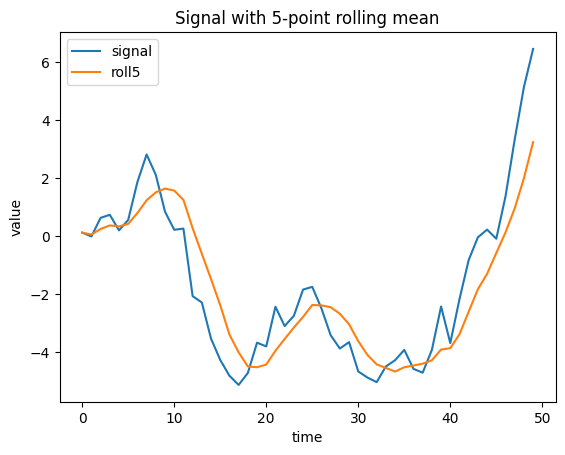

In [46]:
group_means = df.groupby("group")["signal"].mean()
print("Group means:\n", group_means)

# let us smooth the solutions.

df["roll5"] = df["signal"].rolling(window=5, min_periods=1).mean()
ax = df.plot(x="time", y=["signal", "roll5"], title="Signal with 5‑point rolling mean")
ax.set_xlabel("time")
ax.set_ylabel("value")

### 2.3 Read/write CSV

#### 📝 Practice

Download a CSV file, read it with `read_csv` and look at some statistics. 

## 3. Mini‑projects

Short, self‑contained problems you can adapt to your own interests. Each takes a few minutes and is intentionally simple.

### 3.1 Monte Carlo estimation of $\pi$

We sample points uniformly in the unit square and estimate the area of the inscribed quarter‑circle.

In [47]:
N = 200_000
x = np.random.rand(N)
y = np.random.rand(N)
inside = (x**2 + y**2) <= 1.0
pi_est = 4 * inside.mean()
print("Monte Carlo π ≈", pi_est)

Monte Carlo π ≈ 3.15058


#### 📝 Challenge

Check what happens when varying $N$. Plot the results. The curve with the estimated $\pi$ (for each $N$) should be combined with a confidence interval. Here, plot the $2.5\%$ and $97.5\%$ percentages of the samples.

### 3.2 1D heat equation (explicit finite difference)

We solve $u_t = u_{xx}$ on $x \in [0,1]$ with $u(0,t)=u(1,t)=0$ using the explicit scheme. For stability, keep $\alpha = \frac{\Delta t}{\Delta x^2} \le 1/2$.

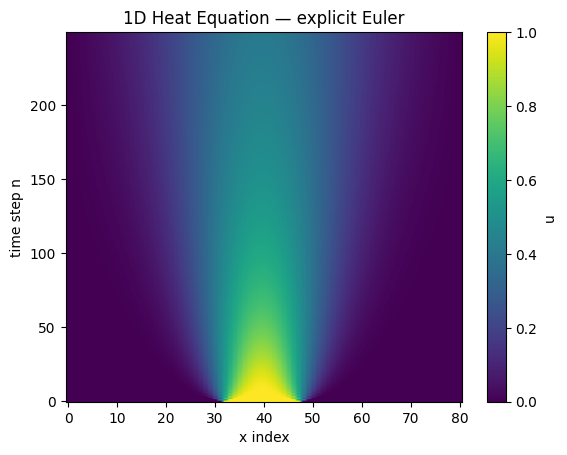

In [48]:
nx, nt = 80, 250
dx = 1.0 / nx
dt = 0.45 * dx**2
alpha = dt / dx**2

u = np.zeros((nt, nx+1))
u[0, int(0.4*nx):int(0.6*nx)] = 1.0

for n in range(nt-1):
    u[n+1, 1:-1] = u[n, 1:-1] + alpha * (u[n, 2:] - 2*u[n, 1:-1] + u[n, :-2])
    u[n+1, 0] = 0.0    # boundary
    u[n+1, -1] = 0.0   # boundary

plt.imshow(u, aspect="auto", origin="lower")
plt.colorbar(label="u")
plt.xlabel("x index"); plt.ylabel("time step n")
plt.title("1D Heat Equation — explicit Euler")
plt.show()

---

### Closing notes
- The goal is comfort, not completeness. Adjust parameters and re‑run to see how behaviour changes.
- When you need more power: look into `scipy.sparse` (large linear algebra), `numba` (speed), and `fenics`/`dolfinx` (PDEs).
- Keep things reproducible: fix random seeds when appropriate and annotate parameters.

**Further reading**
- SciPy: <https://docs.scipy.org/doc/scipy/>
- Pandas: <https://pandas.pydata.org/docs/>
- Matplotlib: <https://matplotlib.org/stable/tutorials/>